In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from adtk.data import validate_series
from adtk.visualization import plot
from adtk.detector import *

In [2]:
# Data source: https://datahub.io/core/global-temp
# https://www.youtube.com/watch?v=T5wB7pk3CUc&t=328s

In [3]:
data = pd.read_csv("temperature.csv.csv")

In [4]:
data.head()

,Source,Year,Mean
0,gcag,1850-01,-0.6746
1,gcag,1850-02,-0.3334
2,gcag,1850-03,-0.5913
3,gcag,1850-04,-0.5887
4,gcag,1850-05,-0.5088


In [5]:
len(data)

3823

In [6]:
data.Source.value_counts()

Source
gcag       2095
GISTEMP    1728
Name: count, dtype: int64

In [7]:
data[data.Source=="GISTEMP"]

,Source,Year,Mean
2095,GISTEMP,1880-01,-0.20
2096,GISTEMP,1880-02,-0.25
2097,GISTEMP,1880-03,-0.09
2098,GISTEMP,1880-04,-0.16
2099,GISTEMP,1880-05,-0.09
...,...,...,...
3818,GISTEMP,2023-08,1.19
3819,GISTEMP,2023-09,1.48
3820,GISTEMP,2023-10,1.34
3821,GISTEMP,2023-11,1.42


In [8]:
data[data.Source == "gcag"]

,Source,Year,Mean
0,gcag,1850-01,-0.6746
1,gcag,1850-02,-0.3334
2,gcag,1850-03,-0.5913
3,gcag,1850-04,-0.5887
4,gcag,1850-05,-0.5088
...,...,...,...
2090,gcag,2024-03,1.2515
2091,gcag,2024-04,1.2053
2092,gcag,2024-05,1.0745
2093,gcag,2024-06,1.1154


In [9]:
data = data.set_index("Year",inplace=True)

In [13]:
data = data["Mean"]

TypeError: 'NoneType' object is not subscriptable

In [11]:
print(data)

None


In [12]:
data["Mean"].plot(figsize=(10, 5), marker="o", title="Time Series Example")
plt.xlabel("Date")
plt.ylabel("Mean")
plt.show()

TypeError: 'NoneType' object is not subscriptable

ValueError: x, y, and format string must not be None

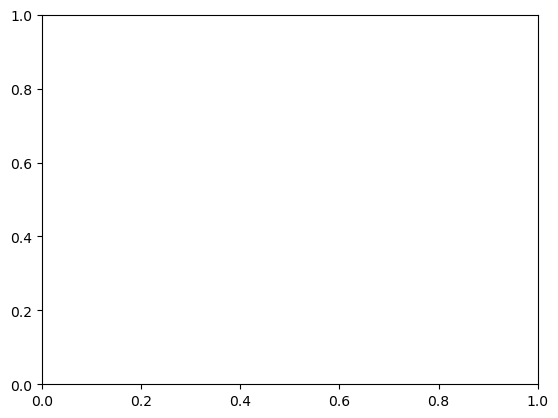

In [12]:
plt.plot(data)

In [ ]:
# Anomaly threshold

In [ ]:
threshold_detector = ThresholdAD(low=-0.5, high=0.75)
anomalies = threshold_detector.detect(data)
plot(data,anomaly=anomalies, anomaly_color="red", anomaly_tag="marker")
plt.show()

In [ ]:
# Sample time series data
data = {
    "date": pd.date_range(start="2023-01-01", periods=10, freq="D"),
    "value": [10, 12, 13, 15, 14, 18, 20, 19, 21, 25]
}
df = pd.DataFrame(data)
df.set_index("date", inplace=True)  # Set date as index
print(df)

In [ ]:
df["value"].plot(figsize=(10, 5), marker="o", title="Time Series Example")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()